# Example data

> Real, published proximity-labelling hits to try ItemiSet on.

In [ ]:
#| default_exp examples

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *
import pandas as pd
from pathlib import Path
from itemiset.layout import layout_sets, check_layout
from itemiset.render import plot

The examples come from **Youn et al. (2018)**, who ran BioID on 119 human proteins involved in RNA biology, as curated by **BioGRID** (release 5.0.262, MIT License). [`data/README.md`](https://github.com/adamcc/itemiset/blob/main/data/README.md) says exactly how the file was cut from BioGRID's download.

> Youn J-Y *et al.* (2018). High-density proximity mapping reveals the subcellular organization of mRNA-associated granules and bodies. *Molecular Cell* 69:517–532. [doi:10.1016/j.molcel.2017.12.020](https://doi.org/10.1016/j.molcel.2017.12.020)

Two examples are built here:

- **`pbody`**: three P-body baits, DDX6, LSM14A and EIF4ENIF1 (4E-T). These are the three proteins needed for P-body assembly in every condition Ayache *et al.* (2015) tested, so their hits overlap heavily: 101 preys, all seven zones filled.
- **`decay`**: DDX6, PRRC2B and the exonuclease XRN1. No prey is shared by DDX6 and PRRC2B alone, which makes it a good test of Venn mode (`show_empty=True`).

Each prey also gets a real number to play with: how many of the study's 118 baits found it. Common hits like the CCR4–NOT subunits are found by dozens of baits, and rarer ones by only a few.

In [ ]:
#| export
import json
from importlib.resources import files

In [ ]:
#| export
def load_example(name: str = "pbody") -> dict:
    "Load a bundled example: a dict with `sets`, `categories`, `category_colours`, `scores` and text describing it."
    data = json.loads(files("itemiset").joinpath("data/examples.json").read_text(encoding="utf-8"))
    if name not in data:
        raise KeyError(f"No example called {name!r}; choose from {sorted(data)}")
    ex = data[name]
    return {**ex, "sets": {k: v for k, v in ex["sets"]}}

## Building the examples

The rest of this notebook rebuilds `itemiset/data/examples.json` (for Python) and `site/assets/example-data.js` (for the website) from the BioGRID file.

In [ ]:
root = Path("..")
bg = pd.read_csv(root/"data/youn2018_biogrid-5.0.262.tab3.txt.gz", sep="\t", dtype=str)
A, B = "Official Symbol Interactor A", "Official Symbol Interactor B"
assert set(bg["Publication Source"]) == {"PUBMED:29395067"}
assert set(bg["Experimental System"]) == {"Proximity Label-MS"}
preys = {bait: sorted(set(g[B]) - {bait}) for bait, g in bg.groupby(A)}
found_by = bg.groupby(B)[A].nunique().to_dict()
len(preys), len(bg)

(118, 7489)

Illustrative groupings by gene family, to show how categories colour the names. They aren't GO annotations.

In [ ]:
GROUPS = {
    "Decapping": ["DCP1A", "DCP1B", "DCP2", "EDC3", "EDC4"],
    "CCR4–NOT": ["CNOT1", "CNOT2", "CNOT3", "CNOT4", "CNOT6", "CNOT6L", "CNOT7", "CNOT8", "CNOT10", "CNOT11", "RQCD1"],
    "miRISC": ["AGO1", "AGO2", "AGO3", "TNRC6A", "TNRC6B", "TNRC6C"],
}
COLOURS = {"Decapping": "#C8102E", "CCR4–NOT": "#2140A8", "miRISC": "#7B2A86"}

def make_example(baits, title, description):
    sets = [[b, preys[b]] for b in baits]
    union = sorted({p for _, v in sets for p in v})
    cats = {g: c for c, gs in GROUPS.items() for g in gs if g in union}
    return dict(title=title, description=description,
                source="Youn et al. (2018) Mol Cell 69:517, via BioGRID 5.0.262 (MIT License)",
                sets=sets, categories=cats,
                category_colours={c: COLOURS[c] for c in COLOURS if c in cats.values()},
                scores={p: int(found_by[p]) for p in union},
                score_label="Number of the study's 118 baits that found this protein")

examples = {
    "pbody": make_example(["DDX6", "LSM14A", "EIF4ENIF1"], "P-body baits",
                          "Proteins found by BioID with three P-body baits in human cells."),
    "decay": make_example(["DDX6", "PRRC2B", "XRN1"], "Decay baits",
                          "DDX6, PRRC2B and XRN1. No prey is shared by DDX6 and PRRC2B alone."),
}
{k: [(n, len(v)) for n, v in ex["sets"]] for k, ex in examples.items()}

{'pbody': [('DDX6', 42), ('LSM14A', 84), ('EIF4ENIF1', 62)],
 'decay': [('DDX6', 42), ('PRRC2B', 30), ('XRN1', 44)]}

Write the files only if they've changed, so rerunning this notebook doesn't touch them:

In [ ]:
def write_if_changed(path, text):
    path = Path(path)
    if path.exists() and path.read_text(encoding="utf-8") == text: return False
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return True

js = json.dumps(examples, ensure_ascii=False, indent=1)
write_if_changed(root/"itemiset/data/examples.json", js + "\n")
write_if_changed(root/"site/assets/example-data.js",
                 "// Generated by nbs/05_examples.ipynb. Do not edit by hand.\n"
                 f"window.ITEMISET_EXAMPLES = {js};\n")

False

## Using an example

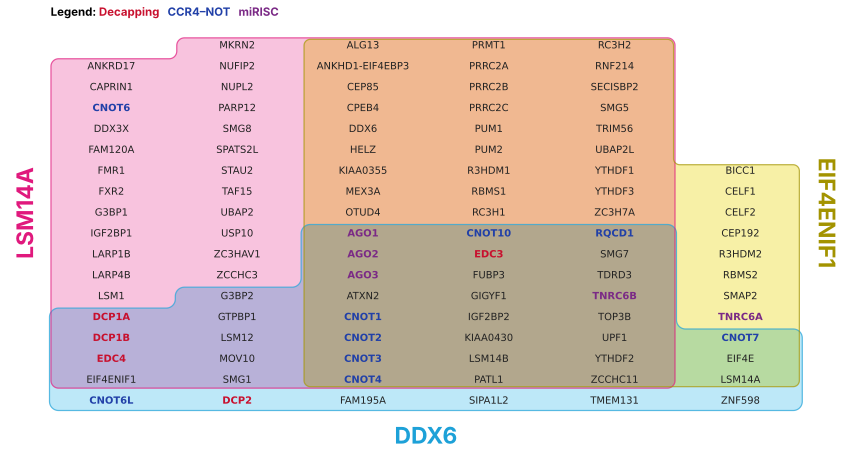

In [ ]:
ex = load_example("pbody")
lay = plot(ex["sets"], categories=ex["categories"], category_colours=ex["category_colours"])
lay

In [ ]:
test_eq(lay.n_items, 101)
counts = {" & ".join(n for n in lay.names if n in z): k for z, k in lay.counts.items()}
test_eq(counts, {"DDX6": 6, "LSM14A": 24, "EIF4ENIF1": 8, "DDX6 & LSM14A": 9, "DDX6 & EIF4ENIF1": 3,
                 "LSM14A & EIF4ENIF1": 27, "DDX6 & LSM14A & EIF4ENIF1": 24})
assert all(check_layout(lay, ex["sets"]).values())

The `decay` example has one empty zone, which Venn mode shows as a ∅ cell:

["1 empty zone(s) shown as '∅' placeholder cells (1 cell each; not area-proportional)."]


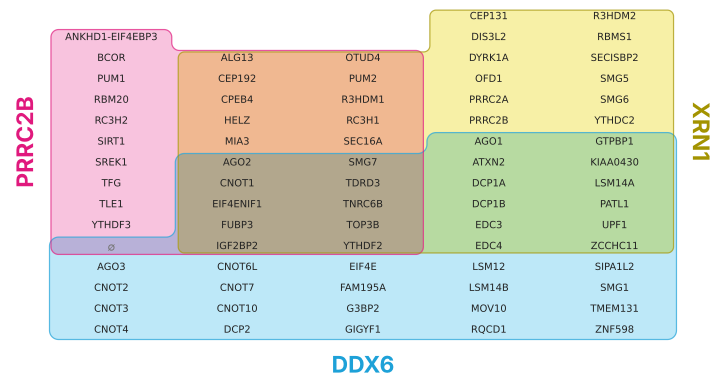

In [ ]:
ex2 = load_example("decay")
lay2 = plot(ex2["sets"], show_empty=True)
print(lay2.notes)
lay2

In [ ]:
test_eq(sum(c.placeholder for c in lay2.cells), 1)
test_fail(lambda: load_example("nope"), contains="No example called")

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()